In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
import joblib
import warnings
warnings.filterwarnings('ignore')




In [39]:
%pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [40]:

import streamlit as st

In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [45]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
sns.set_style('whitegrid')

In [42]:
pip install flask

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
import sklearn
from sklearn.linear_model import LogisticRegression

In [47]:
diabetes_dataset = pd.read_csv('diabetes.csv')
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
diabetes_dataset.shape

(768, 9)

In [49]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [50]:
x = diabetes_dataset.drop('Outcome', axis=1)
y = diabetes_dataset['Outcome']
outcome_counts = y.value_counts()
print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


In [51]:
['Pregnancies', 'Glucose', 'BloodPressure',
 'SkinThickness', 'Insulin', 'BMI',
 'DiabetesPedigreeFunction', 'Age']

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [52]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


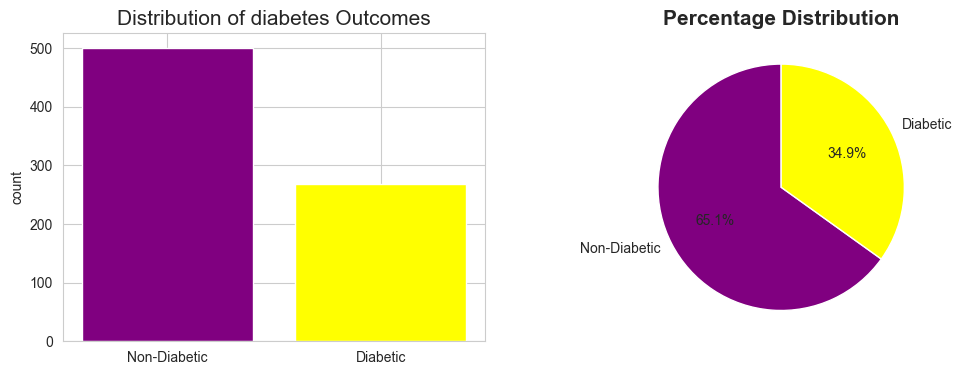

In [53]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
Outcome_counts = diabetes_dataset['Outcome'].value_counts()
plt.bar(['Non-Diabetic','Diabetic'], Outcome_counts.values, color=['Purple','Yellow'])
plt.title('Distribution of diabetes Outcomes', fontsize=15)
plt.ylabel('count')

plt.subplot(1,2,2)
plt.pie(Outcome_counts.values, labels=['Non-Diabetic','Diabetic'], autopct='%1.1f%%', colors=['Purple','yellow'], startangle=90)
plt.title('Percentage Distribution', fontsize=15, fontweight='bold')
plt.show()


Text(0.5, 1.0, 'Feature Correlation Heatmap')

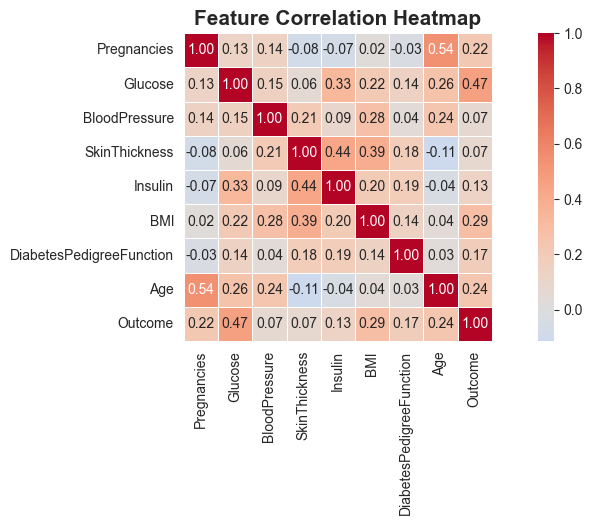

In [54]:
plt.figure(figsize=(12,4))
correlation = diabetes_dataset.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square= True, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')

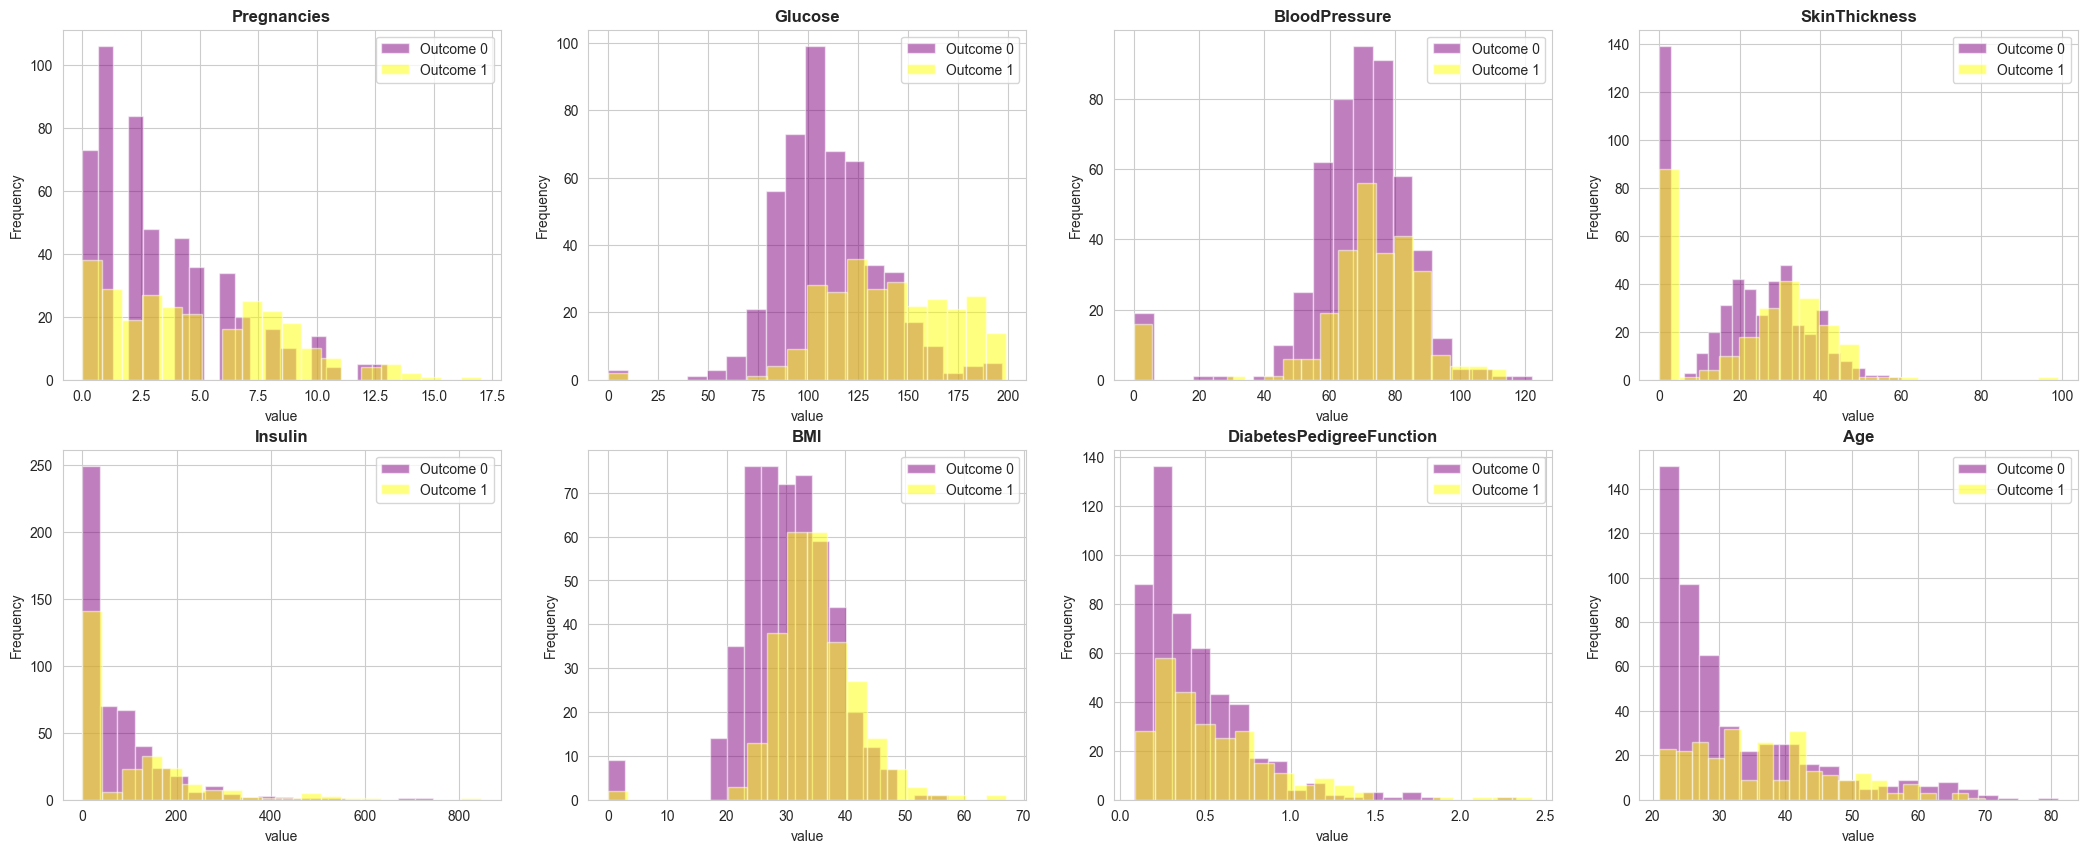

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(26, 10))
features = diabetes_dataset.columns[:-1]

color_map = {0: 'Purple', 1: 'yellow'}

for idx, feature in enumerate(features):
    row, col = idx // 4, idx % 4
    for Outcome in [0, 1]:
        data = diabetes_dataset[diabetes_dataset['Outcome'] == Outcome][feature]
        axes[row, col].hist(data, alpha=0.5, bins=20, label=f'Outcome {Outcome}',
                            color=color_map[Outcome])
    axes[row, col].set_title(feature, fontweight='bold')
    axes[row, col].set_xlabel('value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.show()

In [24]:
X = diabetes_dataset.drop('Outcome', axis=1)
Y = diabetes_dataset['Outcome']

print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [26]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify= Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


In [27]:
classifier = svm.SVC(kernel='linear',probability=True)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pickle

# 1️⃣ Load dataset
data = pd.read_csv("diabetes.csv")

# 2️⃣ Separate X and y
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 3️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4️⃣ Scale data (IMPORTANT for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5️⃣ Create SVM model
model = SVC(kernel='linear')

# 6️⃣ Train model (DO NOT reassign)
model.fit(X_train, y_train)

print("Model type:", type(model))  # MUST NOT be None

# 7️⃣ Save BOTH model and scaler together
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump((model, scaler), f)

print("Model and scaler saved successfully")

Model type: <class 'sklearn.svm._classes.SVC'>
Model and scaler saved successfully


In [30]:
x_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
training_data_accuracy

0.6530944625407166

In [31]:
x_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
test_data_accuracy

0.6428571428571429

In [32]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision, recall, f1)

0.0 0.0 0.0


In [33]:
csv_svm = confusion_matrix(y_test, x_test_prediction)
csv_svm

array([[99,  0],
       [55,  0]])

Text(0.5, 3.722222222222216, 'Predicted')

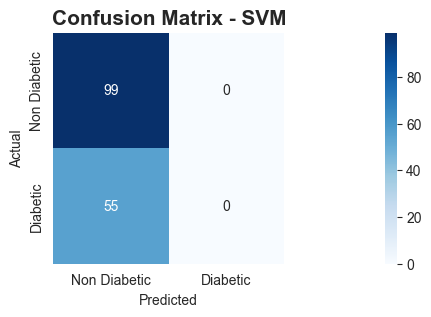

In [34]:
plt.figure(figsize=(26,3))
sns.heatmap(csv_svm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non Diabetic', 'Diabetic'],
            yticklabels=['Non Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - SVM', fontsize=15, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
           
        

In [35]:
input_data = (5,166,72,19,175,25.8,0.587,51)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = classifier.predict(input_data_reshaped)
print(prediction)

[1]


In [36]:
%pip install flask

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [37]:
import flask

In [38]:
from flask import Flask

In [33]:
pip install Scikit-Learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
